# PU experiments

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [3]:
EXPERIMENT = "label_noise"

In [4]:
df = load_experiment_results(name=EXPERIMENT,n=0)
# df = df[df["model"]!="oracle"]
# df["model"] = "classic"
df.model

0        classic
1          naive
2         oracle
3      two_model
4        classic
         ...    
955    two_model
956      classic
957        naive
958       oracle
959    two_model
Name: model, Length: 960, dtype: object

In [5]:
def remove_failed_experiments(df):
    """Remove failed experiments from the dataframe."""
    idx = df.loc[(df["0 precision"]==0) | (df["0 recall"]==0) | (df["1 precision"]==0) | (df["1 recall"]==0)].index
    return df.drop(index=idx)

print("Before removing failed experiments:", df.shape)
df = remove_failed_experiments(df)
print("After removing failed experiments:", df.shape)

Before removing failed experiments: (960, 15)
After removing failed experiments: (693, 15)


In [6]:
# df_old = load_experiment_results(name=EXPERIMENT,n=1)
# df_old = df_old[(df_old["model"]!="oracle") & (df_old["model"]!="classic")] 
# df_old = df_old[(df_old["dataset"]=="mnist")] 
# df = pd.concat([df_old,df],axis=0)
# df

In [7]:
# df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
# df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
# df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df["f1"] = df["1 f1"]
df["precision"] = df["1 precision"]
df["recall"] = df["1 recall"]


df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,693.000000,693.000000,693.000000
mean,0.702158,0.651223,0.603841
std,0.225306,0.313852,0.268336
min,0.166700,0.000700,0.001500
25%,0.484500,0.444400,0.487300
50%,0.740700,0.704200,0.600900
75%,0.912700,0.943700,0.826400
max,1.000000,1.000000,0.995000


In [8]:
fig_experiment_folder = EXPERIMENT
fig_experiment_folder = os.path.join("output",fig_experiment_folder)
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [9]:
# df = df.loc[df[EXPERIMENT].isin([0.005,0.01,0.1,0.2,0.250.5,0.75,1])]

In [10]:
df

,label_noise,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,calculated_c,feature,f1,precision,recall
2,0.05,mock,0,oracle,0.621538,0.613924,0.888889,0.994872,0.061538,0.759295,0.115108,195,130,0.0,,0.1151,0.8889,0.0615
3,0.05,mock,0,two_model,0.406154,1.000000,0.402477,0.010256,1.000000,0.020305,0.573951,195,130,0.0,,0.5740,0.4025,1.0000
6,0.05,mock,1,oracle,0.670769,0.653846,0.794872,0.958974,0.238462,0.777547,0.366864,195,130,0.0,,0.3669,0.7949,0.2385
7,0.05,mock,1,two_model,0.621538,0.961538,0.514170,0.384615,0.976923,0.549451,0.673740,195,130,0.0,,0.6737,0.5142,0.9769
10,0.05,mock,2,oracle,0.819018,0.768627,1.000000,1.000000,0.546154,0.869180,0.706468,196,130,0.0,,0.7065,1.0000,0.5462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,0.50,mnist,8,two_model,0.522019,0.533477,0.510684,0.518908,0.525275,0.526092,0.517876,1428,1365,0.0,,0.5179,0.5107,0.5253
956,0.50,mnist,9,classic,0.511636,0.511478,0.600000,0.998599,0.002198,0.676471,0.004380,1428,1365,0.0,,0.0044,0.6000,0.0022
957,0.50,mnist,9,naive,0.505908,0.510480,0.485089,0.818627,0.178755,0.628833,0.261242,1428,1365,0.0,,0.2612,0.4851,0.1788
958,0.50,mnist,9,oracle,0.476549,0.488045,0.464624,0.485994,0.466667,0.487018,0.465643,1428,1365,0.0,,0.4656,0.4646,0.4667


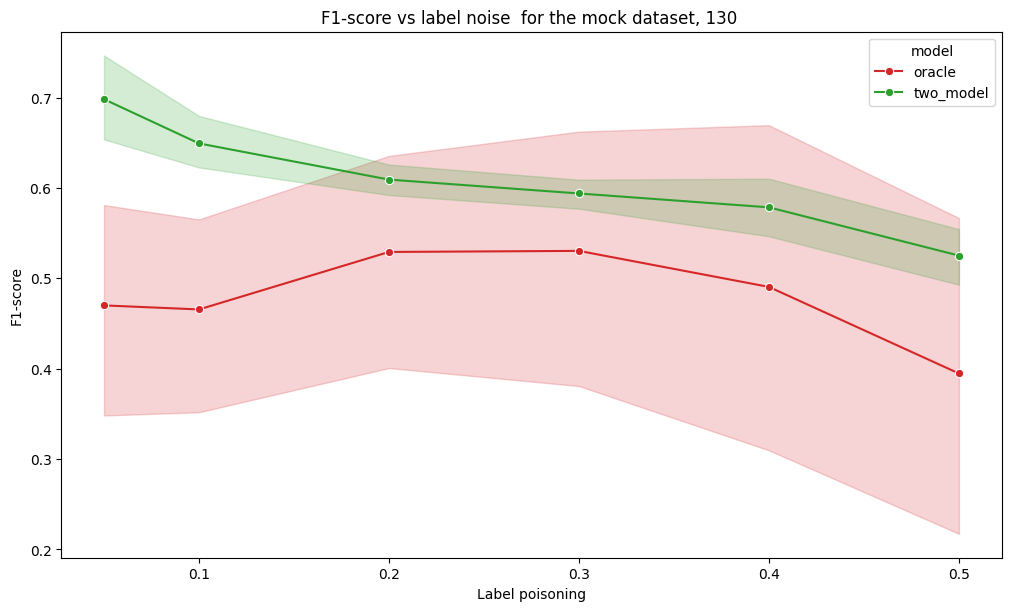

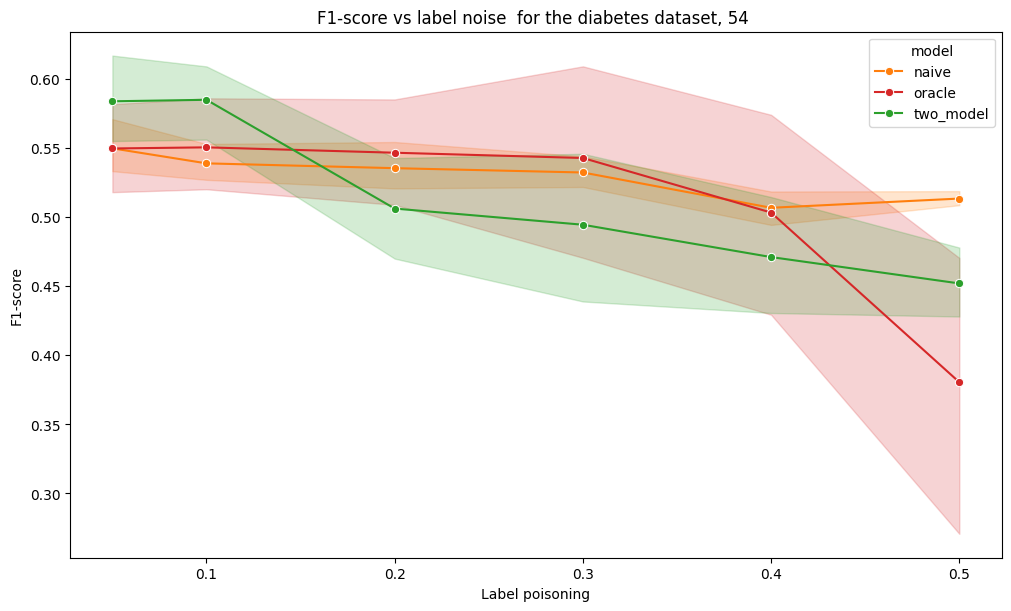

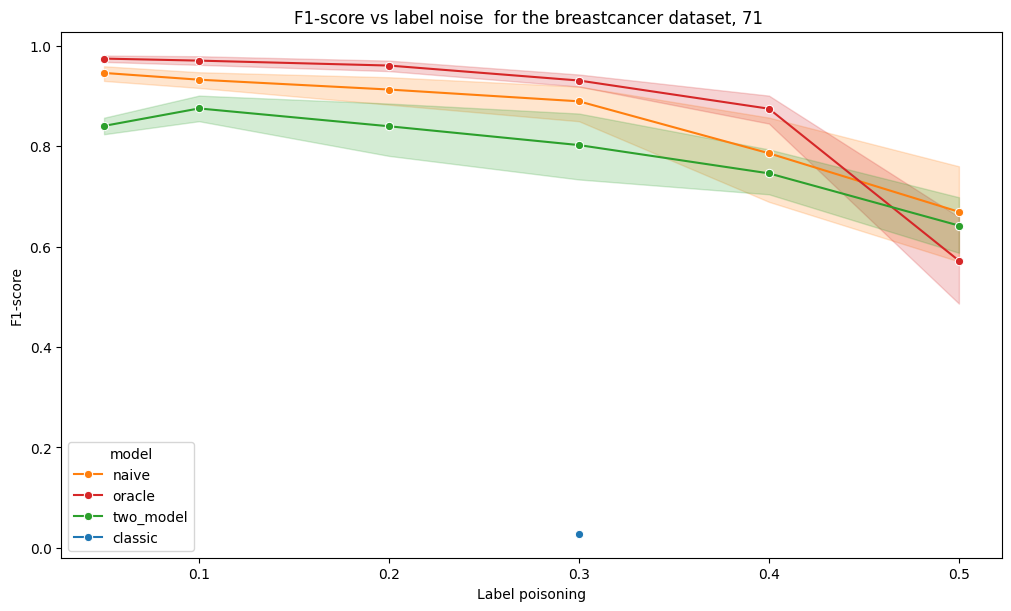

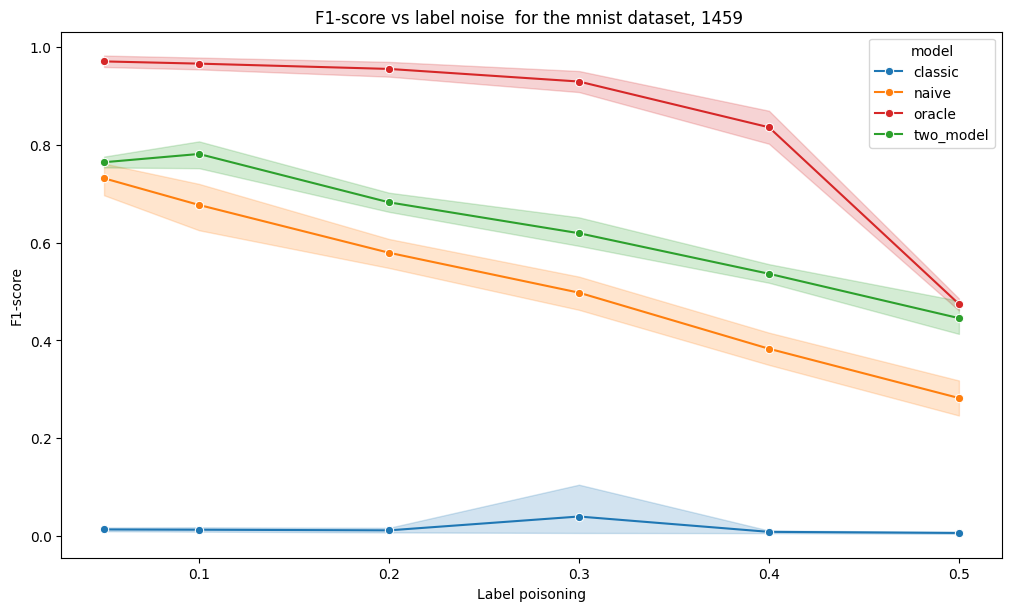

In [13]:

for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    # c = df["c"].unique().tolist()
    # n_labels = get_n_labels(dataset, df["c"].unique())
    # ticks = [n_labels[val] for val in c]
    # plt.figure(figsize=(10, 6),layout='constrained')
    # sns.lineplot(data=df[df["dataset"]==dataset], x=EXPERIMENT,y="precision",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    # # plt.title(f"Macro precision vs c for the {dataset} dataset, {n_labels['title']} ")
    # plt.ylabel("Macro precision")
    # # plt.xticks(c[2:], ticks[2:],rotation=45)

    # plt.xlabel("Label frequency (c | n labels)")
    # plt.savefig(os.path.join(fig_folder,f"Precision_macro_{dataset}.png"))
    # plt.show()

    # plt.figure(figsize=(10, 6),layout='constrained')
    # sns.lineplot(data=df[df["dataset"]==dataset], x=EXPERIMENT,y="recall",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    # # plt.title(f"Macro recall vs c for the {dataset} dataset, {n_labels['title']} ")
    # plt.ylabel("Macro recall")
    # # plt.xticks(c[2:], ticks[2:],rotation=45)
    # plt.xlabel("Label frequency (c | n labels)")
    # plt.savefig(os.path.join(fig_folder,f"Recall_macro_{dataset}.png"))
    # plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x=EXPERIMENT,y="f1",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2","oracle":"C3"})
    plt.title(f"F1-score vs label noise  for the {dataset} dataset, {df.loc[df['dataset']==dataset,'1 support'].max()} ")
    plt.ylabel("F1-score")
    # plt.xticks(c, ticks,rotation=45)
    plt.xlabel("Label poisoning")
    plt.savefig(os.path.join(fig_folder,f"F1_1_{dataset}.png"))
    plt.show()
